In [64]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
#creating dataframe object using pandas
df = pd.read_csv(r"C:\Users\jorrik\Documents\learning\0NaresIT\indian-food-analysis\data\indian_food.csv.csv")
df


,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
0,Balu shahi,"Maida flour, yogurt, oil, sugar",vegetarian,45,25,sweet,dessert,West Bengal,East
1,Boondi,"Gram flour, ghee, sugar",vegetarian,80,30,sweet,dessert,Rajasthan,West
2,Gajar ka halwa,"Carrots, milk, sugar, ghee, cashews, raisins",vegetarian,15,60,sweet,dessert,Punjab,North
3,Ghevar,"Flour, ghee, kewra, milk, clarified butter, su...",vegetarian,15,30,sweet,dessert,Rajasthan,West
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",vegetarian,15,40,sweet,dessert,West Bengal,East
...,...,...,...,...,...,...,...,...,...
250,Til Pitha,"Glutinous rice, black sesame seeds, gur",vegetarian,5,30,sweet,dessert,Assam,North East
251,Bebinca,"Coconut milk, egg yolks, clarified butter, all...",vegetarian,20,60,sweet,dessert,Goa,West
252,Shufta,"Cottage cheese, dry dates, dried rose petals, ...",vegetarian,-1,-1,sweet,dessert,Jammu & Kashmir,North
253,Mawa Bati,"Milk powder, dry fruits, arrowroot powder, all...",vegetarian,20,45,sweet,dessert,Madhya Pradesh,Central


In [66]:
df.info() # basic info about columns and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            255 non-null    object
 1   ingredients     255 non-null    object
 2   diet            255 non-null    object
 3   prep_time       255 non-null    int64 
 4   cook_time       255 non-null    int64 
 5   flavor_profile  255 non-null    object
 6   course          255 non-null    object
 7   state           255 non-null    object
 8   region          254 non-null    object
dtypes: int64(2), object(7)
memory usage: 18.1+ KB


In [40]:
#understanding Data
df.head() 

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
0,Balu shahi,"Maida flour, yogurt, oil, sugar",vegetarian,45,25,sweet,dessert,West Bengal,East
1,Boondi,"Gram flour, ghee, sugar",vegetarian,80,30,sweet,dessert,Rajasthan,West
2,Gajar ka halwa,"Carrots, milk, sugar, ghee, cashews, raisins",vegetarian,15,60,sweet,dessert,Punjab,North
3,Ghevar,"Flour, ghee, kewra, milk, clarified butter, su...",vegetarian,15,30,sweet,dessert,Rajasthan,West
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",vegetarian,15,40,sweet,dessert,West Bengal,East


In [41]:
df.tail()

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
250,Til Pitha,"Glutinous rice, black sesame seeds, gur",vegetarian,5,30,sweet,dessert,Assam,North East
251,Bebinca,"Coconut milk, egg yolks, clarified butter, all...",vegetarian,20,60,sweet,dessert,Goa,West
252,Shufta,"Cottage cheese, dry dates, dried rose petals, ...",vegetarian,-1,-1,sweet,dessert,Jammu & Kashmir,North
253,Mawa Bati,"Milk powder, dry fruits, arrowroot powder, all...",vegetarian,20,45,sweet,dessert,Madhya Pradesh,Central
254,Pinaca,"Brown rice, fennel seeds, grated coconut, blac...",vegetarian,-1,-1,sweet,dessert,Goa,West


In [42]:
df.isnull().sum()

name              0
ingredients       0
diet              0
prep_time         0
cook_time         0
flavor_profile    0
course            0
state             0
region            1
dtype: int64

In [67]:
df.describe()

,prep_time,cook_time
count,255.000000,255.000000
mean,31.105882,34.529412
std,72.554409,48.265650
min,-1.000000,-1.000000
25%,10.000000,20.000000
50%,10.000000,30.000000
75%,20.000000,40.000000
max,500.000000,720.000000


In [68]:
#Observations
#1.region has 1 null value
#2.df.tail() and df.describe() shows prep_time and cook_time as -1 in some rows

In [89]:
# filling nulls in region with unknown
df["region"].fillna("Unknown", inplace = True) 


C:\Users\jorrik\AppData\Local\Temp\ipykernel_13484\1460569930.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["region"].fillna("Unknown", inplace = True)


In [93]:
df["region"] = df["region"].replace("-1", "Unknown")
df["region"].value_counts()

region
West          74
South         59
North         49
East          31
North East    25
Unknown       14
Central        3
Name: count, dtype: int64

In [94]:
df["region"].isnull().sum() # no nulls in region after edit

np.int64(0)

In [71]:
# handling -1 in preptime and cook_time
df["prep_time"] = df["prep_time"].replace( -1 , df["prep_time"].median())
df["cook_time"] = df["cook_time"].replace( -1 , df["cook_time"].median())

In [74]:
df["prep_time"].min()

5

In [73]:
df["cook_time"].min()

2

In [75]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [76]:
# Check missing again
df.isnull().sum()

name              0
ingredients       0
diet              0
prep_time         0
cook_time         0
flavor_profile    0
course            0
state             0
region            0
dtype: int64

In [79]:
#FEATURE ENGINEERING


In [82]:
#TOTAL TIME
df["total_time"] = df["cook_time"] + df["prep_time"]
df["total_time"]

0       70
1      110
2       75
3       45
4       55
      ... 
250     35
251     80
252     40
253     65
254     40
Name: total_time, Length: 255, dtype: int64

In [84]:
#category
df["category"] = df["total_time"].apply( lambda x : "Quick" if x < 30 else "Medium" if x < 60 else "Slow")


In [86]:
#expensive
df["expensive"] = df["total_time"] > 60

In [95]:
#KPI Analysis
#KPI 1: Region with most dishes # west region
df["region"].value_counts().sort_values(ascending = False)

region
West          74
South         59
North         49
East          31
North East    25
Unknown       14
Central        3
Name: count, dtype: int64

In [96]:
#KPI 2: Avg cooking time by diet
df.groupby("diet")["cook_time"].mean()

diet
non vegetarian    36.551724
vegetarian        38.110619
Name: cook_time, dtype: float64

In [100]:
#KPI 3 most time consuming dish
df.loc[df["total_time"].idxmax()]

name                                   Shrikhand
ingredients       Curd, sugar, saffron, cardamom
diet                                  vegetarian
prep_time                                     10
cook_time                                    720
flavor_profile                             sweet
course                                   dessert
state                                Maharashtra
region                                      West
total_time                                   730
category                                    Slow
expensive                                   True
Name: 62, dtype: object

In [106]:
#KPI 4: Top 3 regions
(df.groupby("region")["name"].count()).nlargest(3)

region
West     74
South    59
North    49
Name: name, dtype: int64

In [109]:
#kpi3 most common category
df["category"].value_counts().idxmax()

'Medium'

In [ ]:
#visuals

Text(0.5, 1.0, 'Number of dishes per region')

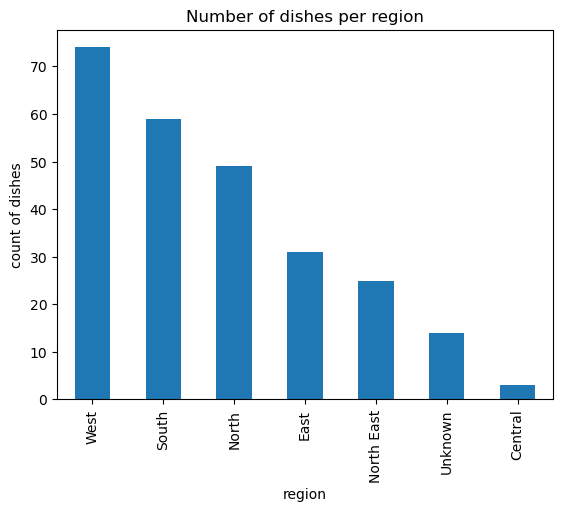

In [115]:
df["region"].value_counts().plot(kind = "bar")
plt.xlabel("region")
plt.ylabel("count of dishes")
plt.title("Number of dishes per region")

Text(0.5, 1.0, 'Veg vs Non-Veg Distribution')

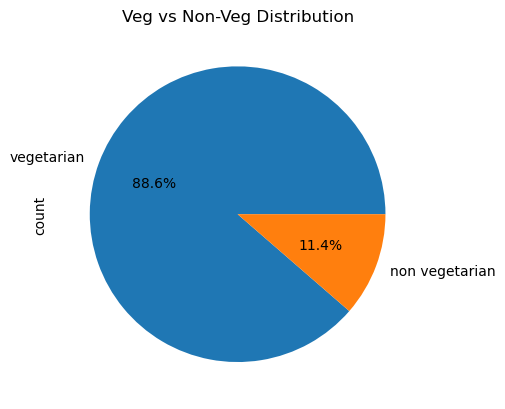

In [123]:
# veg vs non veg distribution
df["diet"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Veg vs Non-Veg Distribution")


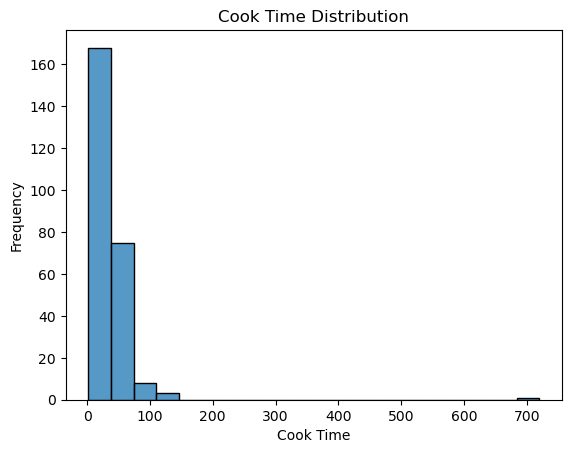

In [126]:
# Cook Time Distribution
sns.histplot( data = df["cook_time"] ,bins = 20)
plt.title("Cook Time Distribution")
plt.xlabel("Cook Time")
plt.ylabel("Frequency")
plt.show()

<Axes: xlabel='region', ylabel='cook_time'>

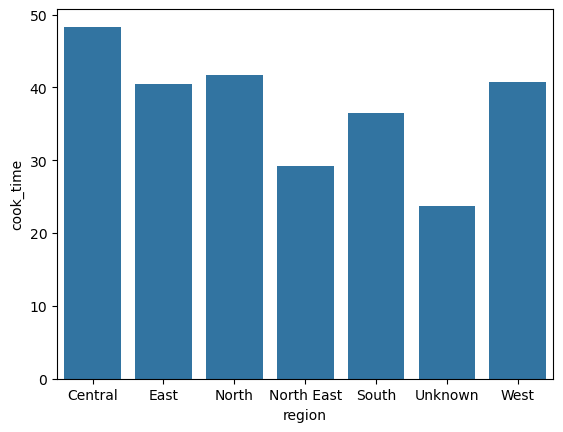

In [133]:
# avg cooktime per region 
dataa = df.groupby("region")["cook_time"].mean().reset_index()
sns.barplot(x="region", y="cook_time", data=dataa)


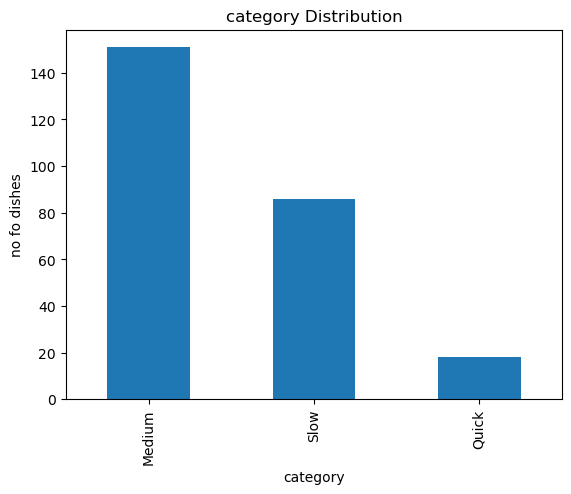

In [141]:
# category distribution

df["category"].value_counts().plot( kind = "bar")
plt.title("category Distribution")
plt.xlabel("category")
plt.ylabel("no fo dishes")
plt.show()

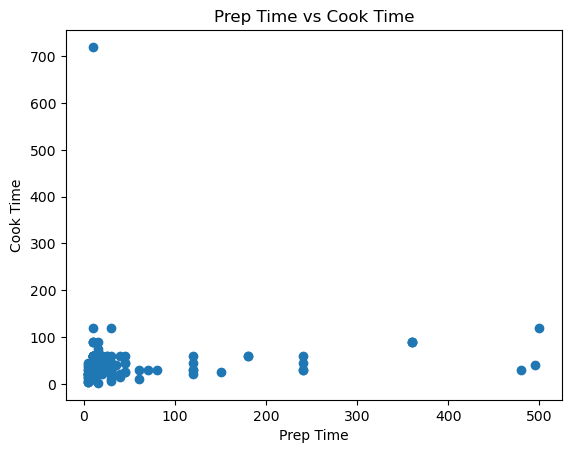

In [142]:
plt.scatter(df["prep_time"], df["cook_time"])
plt.title("Prep Time vs Cook Time")
plt.xlabel("Prep Time")
plt.ylabel("Cook Time")
plt.show()